# EDA + Lista de Leakage — Bank Marketing

**Etapa E1 · Eng. de Dados.** Objetivo: entender a base *antes* de modelar, expor o
desbalanceamento e os valores ausentes disfarçados, e **identificar features de vazamento
temporal (leakage)** a serem removidas.

- **Base:** data/kaggle/bank-additional-full.csv (41.188 × 21) — ver
  [dicionário de dados](../docs/data-dictionary.md).
- **Atenção:** esta variante (*bank-additional*) **não tem coluna balance (saldo)**;

## 1. Setup e carga

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations
from kaggle.api.kaggle_api_extended import KaggleApi

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [21]:
def download_dataset_kaggle(dataset: str, destination: Path) -> None:
    try:
        api = KaggleApi()
        api.authenticate()
    except Exception as ex:
        print(ex)
        return None
    try:
        api.dataset_download_files(
            dataset,
            path=str(destination),
            unzip=True,
            quiet=True,
        )
    except Exception as e:
        print(e)

    return None

In [22]:
DATA = Path("../data/kaggle/bank-additional-full.csv")

In [23]:
if not DATA.exists():
    download_dataset_kaggle("henriqueyamahata/bank-marketing", DATA)

df = pd.read_csv(DATA, sep=";")

print(f"Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas")

df.head()

Base carregada: 41188 linhas x 21 colunas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Visão geral — shape, tipos e estatísticas

In [24]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

Aqui percebemos que não existem valores nulos, investigar.

### Estatísticas das numéricas.

**Cuidado:** duration é leakage e pdays maioria de valores = 999.

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


### Cardinalidade das categóricas

In [26]:
cat_cols = df.select_dtypes(include=["object", "str"]).columns.drop("y")

df[cat_cols].nunique().sort_values(ascending=False).to_frame("n_categorias")

,n_categorias
job,12
month,10
education,8
day_of_week,5
marital,4
default,3
loan,3
housing,3
poutcome,3
contact,2


## 3. Valores ausentes — o "unknown" disfarçado

Esta base **não tem NaN**: o ausente vem como a string "unknown".

In [27]:
df = df.replace("unknown", pd.NA)
miss = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame()
    .rename(columns={0: "missing"})
    .query("missing > 0")
)
miss["pct_missing"] = miss.apply(lambda x: (x / len(df) * 100).round(2))
miss

,missing,pct_missing
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  str    
 2   marital         41108 non-null  str    
 3   education       39457 non-null  str    
 4   default         32591 non-null  str    
 5   housing         40198 non-null  str    
 6   loan            40198 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [29]:
df[df["housing"].isna()][["housing", "loan"]]

,housing,loan
29,NaN,NaN
81,NaN,NaN
261,NaN,NaN
385,NaN,NaN
401,NaN,NaN
...,...,...
40990,NaN,NaN
41014,NaN,NaN
41015,NaN,NaN
41029,NaN,NaN


housing e loan têm exatamente o mesmo nº de ausentes e ocorrem juntos

## 4. Variável alvo y — desbalanceamento

In [30]:
y_dist = df.y.value_counts(normalize=True).mul(100).round(2)

print(y_dist.to_string())


y
no     88.73
yes    11.27


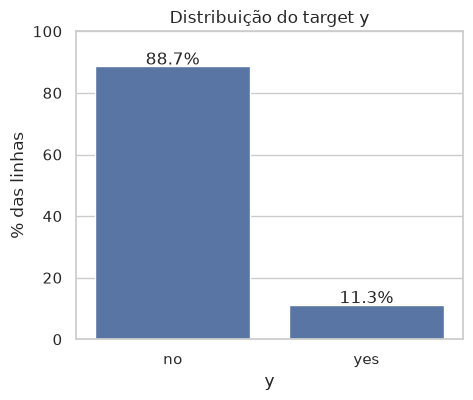

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=y_dist.index, y=y_dist.values, ax=ax)
for i, v in enumerate(y_dist.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
ax.set(
    title="Distribuição do target y", ylabel="% das linhas", xlabel="y", ylim=(0, 100)
)
plt.show()

Apenas **~11% de yes**. Isso indica necessidade de desbalanceamento (PR-AUC, recall, F1)

## 5. Distribuições e relação com o target

### 5.1 age por y

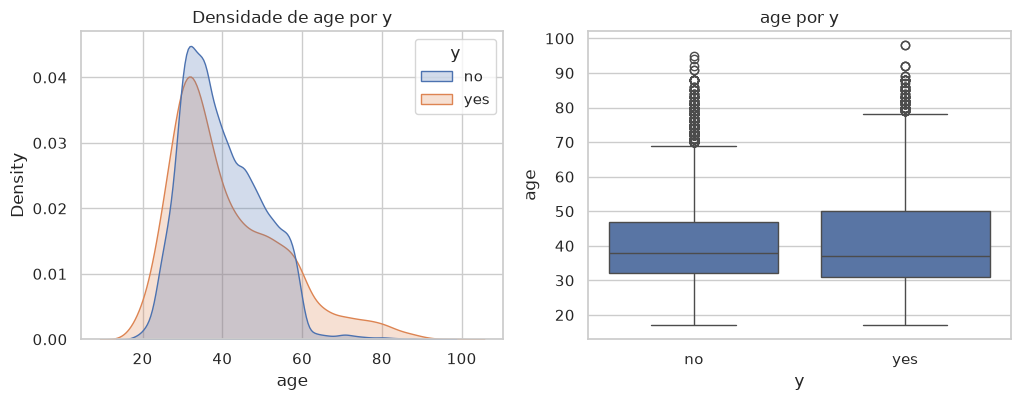

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x="age", hue="y", common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Densidade de age por y")
sns.boxplot(data=df, x="y", y="age", ax=axes[1])
axes[1].set_title("age por y")
plt.show()

### 5.2 Conversão por job

Taxa de yes por profissão vs. a média global (11,3%) — insumo para o contexto sintético
(proxy de renda/segmento).

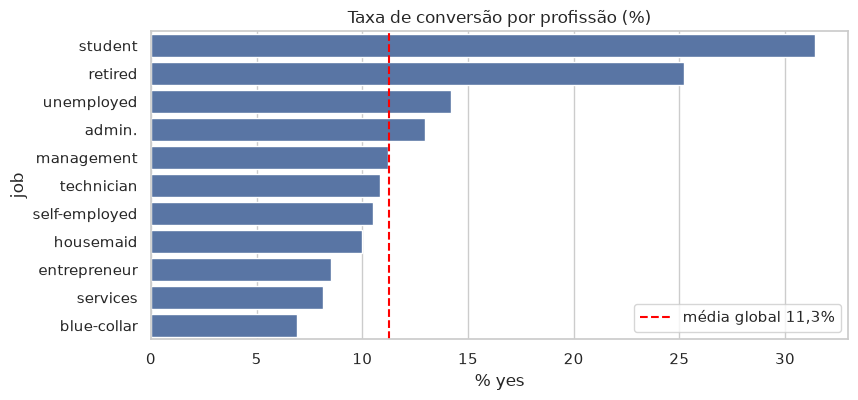

In [33]:
df["y_bin"] = (df.y == "yes").astype(int)
conv_job = (
    df.groupby("job", dropna=False).y_bin.mean().mul(100).sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=conv_job.values, y=conv_job.index.astype(str), ax=ax)
ax.axvline(11.27, ls="--", color="red", label="média global 11,3%")
ax.set(title="Taxa de conversão por profissão (%)", xlabel="% yes")
ax.legend()
plt.show()

### 5.3 default / housing / loan — proxies de capacidade financeira

In [34]:
print(df["default"].value_counts(normalize=True).mul(100).round(2), end="\n\n")
print(
    df.groupby("loan")["y"].value_counts(normalize=True).mul(100).round(2), end="\n\n"
)
print(
    df.groupby("housing")["y"].value_counts(normalize=True).mul(100).round(2),
    end="\n\n",
)

default
no     99.99
yes     0.01
Name: proportion, dtype: float64

loan  y  
no    no     88.66
      yes    11.34
yes   no     89.07
      yes    10.93
Name: proportion, dtype: float64

housing  y  
no       no     89.12
         yes    10.88
yes      no     88.38
         yes    11.62
Name: proportion, dtype: float64



**Achado importante:** default = "yes" tem **apenas 3 linhas** em toda a base.

"negativado = default==yes" é um proxy praticamente vazio

"loan" e "housing" tem distribuições semelhantes em taxa de conversão.

## 6. pdays — sentinela 999

999 significa "cliente nunca contatado antes" — é categórico disfarçado de numérico.
Separamos em uma flag booleana foi_contatado_antes para não poluir estatísticas e modelos.

In [35]:
print("share de pdays == 999:", round((df.pdays == 999).mean(), 4))
df["foi_contatado_antes"] = df.pdays != 999
print("\nConversão (% yes) por foi_contatado_antes:")
print(df.groupby("foi_contatado_antes").y_bin.mean().mul(100).round(2).to_string())

share de pdays == 999: 0.9632

Conversão (% yes) por foi_contatado_antes:
foi_contatado_antes
False     9.26
True     63.83


## 7. Vazamento temporal (leakage)

### 7.1 duration — a prova

duration (duração da ligação) só é conhecida **depois** que a ligação termina — quando o
desfecho já é sabido. O gráfico mostra a separação gritante (média 221s para no vs 553s
para yes; correlação 0,40). **Deve ser removida** do conjunto de modelagem.

y
no     220.8
yes    553.2
corr(duration, y): 0.405


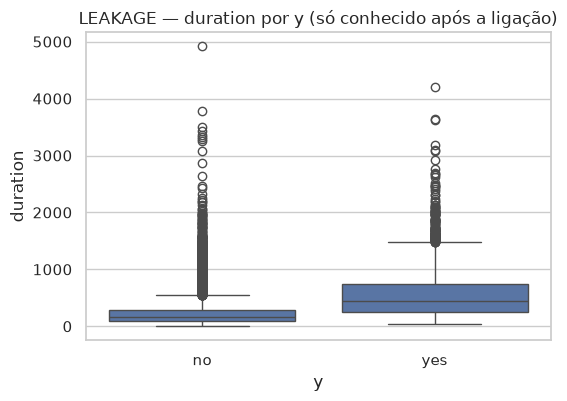

In [36]:
print(df.groupby("y").duration.mean().round(1).to_string())
print("corr(duration, y):", round(df.duration.corr(df.y_bin), 3))
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="y", y="duration", ax=ax)
ax.set_title("LEAKAGE — duration por y (só conhecido após a ligação)")
plt.show()

### 7.2 Indicadores macro — colinearidade e viés temporal

emp.var.rate, euribor3m e nr.employed são quase perfeitamente colineares (0,91–0,97):
codificam *quando* a campanha rodou (regime econômico 2008–2010), não o cliente. Risco de o
modelo aprender "a época" em vez de propensão → **candidatos secundários a leakage temporal**.

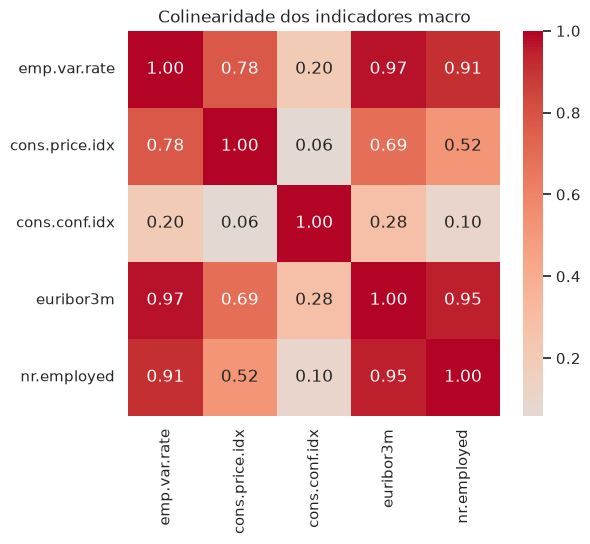

In [37]:
macro = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[macro].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Colinearidade dos indicadores macro")
plt.show()

## 8. Associações entre todas as variáveis (dython)

dython.associations lida com tipos mistos: **Cramér's V** para categórica×categórica e
**correlation ratio (η)** para categórica×numérica — superior a um .corr() que ignoraria as
categóricas. Repare na linha/coluna de duration vs y: a associação alta é justamente o
leakage.

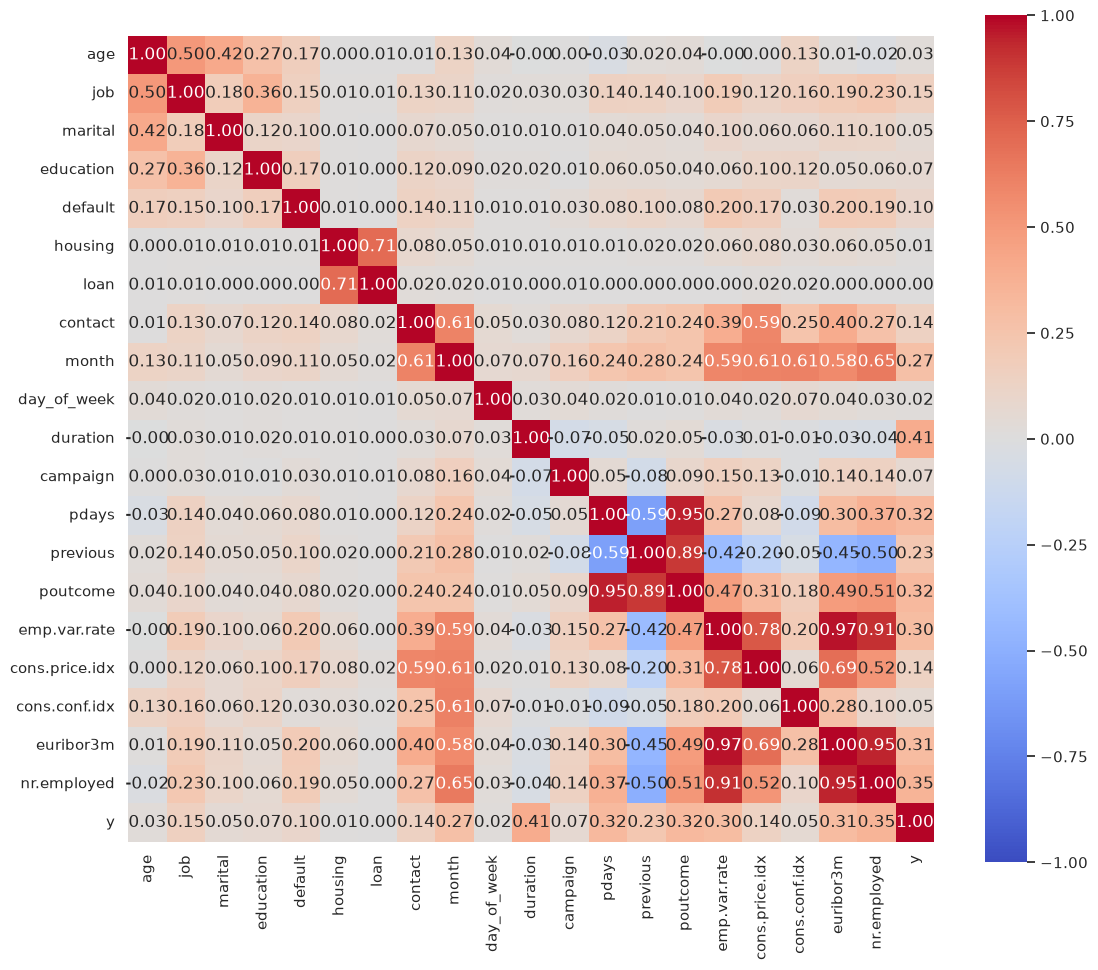

In [38]:
assoc = associations(
    df.drop(columns=["y_bin", "foi_contatado_antes"]),
    nom_nom_assoc="cramer",
    nan_strategy="replace",
    nan_replace_value="ausente",
    figsize=(13, 11),
    cmap="coolwarm",
)
plt.show()

## 9. Features candidatas a leakage

| # | Feature | Veredito | Justificativa |
|---|---------|----------|---------------|
| 1 | duration | **Remover** | Só existe após a ligação; prevê o passado com info do futuro. Corr 0,40 com y; média 221s (no) × 553s (yes). |
| 2 | pdays (=999) | **Transformar** | 96% sentinela 999; usar como flag foi_contatado_antes, não como número cru. |
| 3 | emp.var.rate, euribor3m, nr.employed | **Vigiar / regularizar** | Colineares (0,91–0,97) e proxies do período temporal; risco de o modelo aprender o regime econômico. Avaliar manter só 1 ou nenhum. |
| 4 | poutcome / previous | **Avaliar** | Legítimos (campanha anterior), mas confirmar que não carregam o desfecho atual. |

## 10. Conclusões e próximos passos

- Base com **~11% de positivos** → métricas sensíveis a desbalanceamento.
- Ausentes disfarçados de "unknown"; default (21%) e education (4%) os mais afetados.
- **default="yes" quase inexistente (3 linhas)** → revisar o proxy de "negativado" da E2.
- **duration é o leakage nº 1** e sai do conjunto de modelagem.
- pdays=999 vira flag; indicadores macro ficam sob vigilância (colinearidade/viés temporal).

